In [106]:
import numpy as np
import rebound
import astropy.constants as const
import astropy.units as u
import matplotlib.pyplot as plt
from plotting_params import use_my_style
import glob
import netCDF4
from matplotlib.lines import Line2D
use_my_style()

## 1) Calculate saturated water vapor pressure

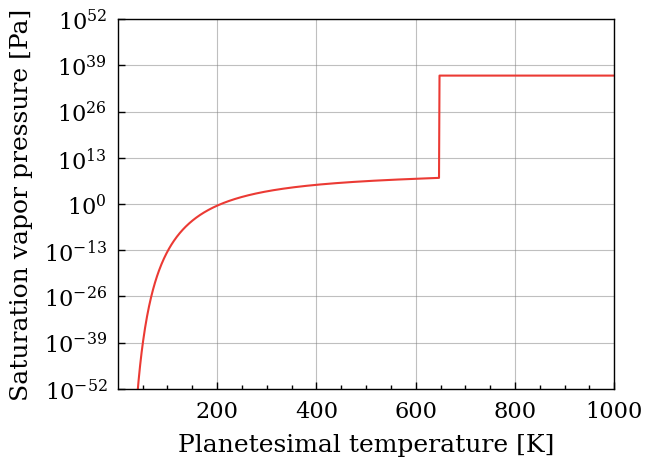

In [57]:
def P_sat_vap(T_pl):

    Pc = ((22.065e6 * u.Pa).to('Msun/(AU*yr2)')).value
    Tc = 647.096 #Kelvin

    T_pl = np.asarray(T_pl, dtype=float)
    P_sat = np.full_like(T_pl, 1e32, dtype=float)
    mask = T_pl < Tc
    T_pl_valid = T_pl[mask]

    theta = T_pl_valid / Tc
    tau = 1 - theta
    a1, a2, a3, a4, a5, a6 = -7.85951783, 1.84408259, -11.7866497, 22.6807411, -15.9618719, 1.80122502
    log_p_over_pc = Tc/T_pl_valid * (a1*tau + a2*tau**1.5 + a3*tau**3 + a4*tau**3.5 + a5*tau**4 + a6*tau**7.5)

    P_sat[mask] = np.exp(log_p_over_pc) * Pc
    
    return P_sat

Ts = np.linspace(1, 1000, 1000)
plt.plot(Ts, (P_sat_vap(Ts)*u.Msun/(u.AU*u.yr**2)).to('Pa').value)
plt.yscale('log')
plt.ylim(1e-52, 1e52)
plt.xlabel('Planetesimal temperature [K]')
plt.ylabel('Saturation vapor pressure [Pa]')
plt.grid()
plt.show()

## 2) Extract min peri from simulations

In [2]:
print(3.4*const.R_sun.to(u.au).value)

0.015811588687271335


### function for doing it for 1 file

In [107]:
files_w_gas_3_pl = glob.glob(f'core_outputs_yr2/gas_drag/*3_pl_single_particle_new.nc')
print(len(files_w_gas_3_pl))

def get_min_peri(filename):

    min_peri_list = []
    final_time = []
    a_list = []
    inc_list = []
    filecount = 0

    with netCDF4.Dataset(filename, 'r') as ncfile:

        test_particles = ncfile['test_particles'][:]
        test_particles = test_particles.filled(np.nan)
        massive_bodies = ncfile['massive_bodies'][:]
        tf = massive_bodies[-1][0][0]/5
        ple, pla = massive_bodies[:, :, 4], massive_bodies[:, :, 5] 
        
        apo_dist_b = pla[:,1] * (1 + ple[:,1]) 
        peri_dist_c = pla[:,2] * (1 - ple[:,2]) 
        c1 = np.all(ple < 1)
        c2 = np.all(apo_dist_b < 0.99*peri_dist_c)
        
        if c1 and c2:
            filecount += 1

            r = np.sqrt(test_particles[:, 1]**2 + test_particles[:, 2]**2 + test_particles[:, 3]**2)
            rsvalid = test_particles[r<10]
            if len(rsvalid) != 0:
                a = rsvalid[:, 5]
                ecc = rsvalid[:,4]
                peris = a * (1 - ecc)
                inc = rsvalid[:, 6]

                #ignore peris inside truncation radius
                perimask = peris > (3.4*const.R_sun.to(u.au).value)
                allowed_peris = peris[perimask]   
                a = a[perimask]
                ecc = ecc[perimask]  
                inc = inc[perimask]
                min_peri = np.min(allowed_peris) 
                min_peri = min_peri[~np.isnan(min_peri)]

                min_a = a[np.argmin(a * (1 - ecc))]
                min_inc = inc[np.argmin(a * (1 - ecc))]

                min_peri_list.append(min_peri)
                a_list.append(min_a)
                inc_list.append(min_inc)
                final_time.append(tf)

                return min_peri_list, a_list, inc_list, final_time, filecount 
            else:
                return None


1179


### function for combining all:

In [110]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def combine_all_particles(filenames):

    min_peri_list = []
    final_times = []
    a_list = []
    inc_list = []
    filecount_total = 0

    with ProcessPoolExecutor(max_workers=50) as executor:

        results = list(tqdm(
            executor.map(get_min_peri, filenames),
            total=len(filenames),
            desc="processing"
        ))

    results = [r for r in results if r is not None]


    for min_peri, a, inc, tfinal, filecount in results:
        min_peri_list.append(min_peri)
        final_times.append(tfinal)
        a_list.append(a)
        inc_list.append(inc)
        filecount_total += filecount

    return min_peri_list, a_list, inc_list, final_times, filecount_total

In [111]:
all_particles_gas = combine_all_particles(files_w_gas_3_pl[:100])

processing: 100%|██████████| 100/100 [00:03<00:00, 28.49it/s]


### format nicely

Peri: 1.922 AU, a: 15.888 AU, inc: 8.36 degrees
Peri: 5.679 AU, a: 19.395 AU, inc: 15.98 degrees
Peri: 8.383 AU, a: 24.192 AU, inc: 4.44 degrees
Peri: 0.016 AU, a: 8.458 AU, inc: 97.99 degrees
Peri: 6.505 AU, a: 15.506 AU, inc: 19.15 degrees
Peri: 4.657 AU, a: 20.093 AU, inc: 7.97 degrees
Peri: 5.286 AU, a: 18.792 AU, inc: 8.38 degrees
Peri: 3.822 AU, a: 16.147 AU, inc: 10.08 degrees
Peri: 0.057 AU, a: 13.851 AU, inc: 148.89 degrees
Peri: 2.844 AU, a: 18.634 AU, inc: 14.35 degrees
Peri: 9.576 AU, a: 13.596 AU, inc: 11.10 degrees
Peri: 0.818 AU, a: 12.853 AU, inc: 7.17 degrees
Peri: 0.151 AU, a: 13.000 AU, inc: 13.10 degrees
Peri: 3.859 AU, a: 18.963 AU, inc: 23.40 degrees
Peri: 8.090 AU, a: 22.373 AU, inc: 7.62 degrees
Peri: 5.934 AU, a: 17.768 AU, inc: 10.48 degrees
Peri: 8.814 AU, a: 22.587 AU, inc: 9.50 degrees
Peri: 6.046 AU, a: 18.149 AU, inc: 10.83 degrees
Peri: 0.093 AU, a: 16.168 AU, inc: 16.86 degrees
Peri: 7.622 AU, a: 19.641 AU, inc: 10.04 degrees
Peri: 4.058 AU, a: 19.778 A

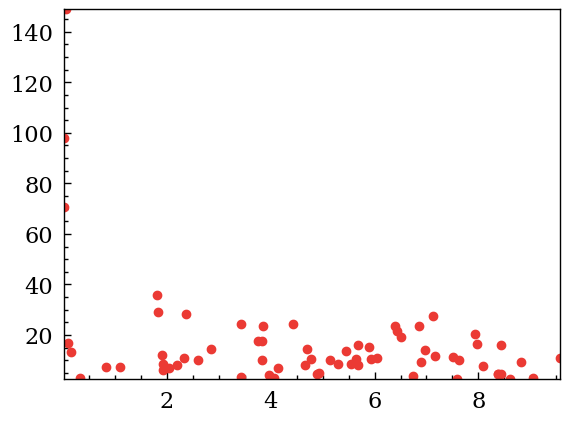

In [118]:
all_peris = np.array([peri[0][0] for peri in all_particles_gas[0] if peri])
all_semimajors = np.array([a[0] for a in all_particles_gas[1] if a])
all_incs = np.array([np.degrees(inc[0]) for inc in all_particles_gas[2] if inc])

for i in range(len(all_peris)):
    print(f"Peri: {all_peris[i]:.3f} AU, a: {all_semimajors[i]:.3f} AU, inc: {all_incs[i]:.2f} degrees")

plt.plot(all_peris, all_incs, 'o')

In [ ]:
#get the min of all mins in each file
arg = np.argmin(all_peris)
min_semimajor = all_semimajors[arg]
min_periastron = all_peris[arg]
min_inclination = all_incs[arg]
print(min_semimajor, min_periastron, min_inclination)

## 2) Calculate velocity of particle at periastron

In [63]:
def velocity_at_peri(a, peri):
    G = const.G
    M_star = const.M_sun * 0.965
    v_peri = np.sqrt(G * M_star * (2/(peri*u.AU) - 1/(a*u.AU)))
    return v_peri.to(u.m/u.s)

velocity_at_peri(min_semimajor, min_periastron).to('km/s')

<Quantity 327.46851345 km / s>

### Calculate gas drag terms

In [10]:
''' constants in AU, yr, M_sun units'''
solid_rho = 1683721.7643842339
sigma_char = 3.038845902395208e-07
lg = 0.00841860882192117 
kb = 3.0898292661510003e-61
kb_si = const.k_B.value
m_proton_si = const.m_p.value
stellar_radius = 1.26 * const.R_sun.to('AU').value
kgtomsun = (1 / const.M_sun).value
dtor = np.pi / 180
r_out = 40 
mu = 2.33
m_proton = 1.6726e-27 * kgtomsun
G = const.G.to('AU**3 / (M_sun * yr**2)').value
M_star = 0.965

def get_GD_terms(peri, semi, r_pl):
    '''first, compute gas density as a function of z'''

    vx, vy, vz = velocity_at_peri(semi, peri).to(u.AU/u.yr).value, 0, 0
    r = peri
    print(r)
    x, y, z = r, 0, 0

    Omega = np.sqrt(G * M_star / r**3)

    T = 38*(r/(40))**(-0.24)  #new temperature profile from pds 70 modelling papers
    
    c_s_si = np.sqrt(kb_si * T / (mu * m_proton_si))  # m/s
    c_s = (c_s_si * u.m/u.s).to(u.AU/u.yr).value  # convert to AU/yr

    H = c_s / Omega
    print(c_s)
    
    surface_density = sigma_char * (r/r_out)**(-1) * np.exp(-r/r_out) #pds 70 papers
    
    if r>=18 and r<=40:
        surface_density *= 0.01 # add a gap

    if r<stellar_radius*3.4:
        surface_density = 0 #no gas inside of 3.4 stellar radii - from pds 70 papers

    gas_density = surface_density / (np.sqrt(2*np.pi) * H) * np.exp(-(z)**2 / (2 * H**2)) #from Eriksson+2021

    'DEFINE GAS VELOCITY'
    v_K = np.sqrt(G * M_star / r)

    theta = np.arctan2(y,x)
    theta = 0
    v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0]) #trig to get correct direction

    v_gas = v_K*v_unit_vector
    v_pl_vector = np.array([vx, vy, vz]) #velocity of planetesimal

    v_rel = v_pl_vector - v_gas 
    v_rel_mag = np.linalg.norm(v_rel)

    'calculate term in min func for stopping time - Eriksson+ 2021'
    Re = 4 * r_pl * v_rel_mag / (c_s * lg)
    C_D = 24/Re * (1+0.27*Re)**(0.43) + 0.47*(1-np.exp(-0.04*Re**(0.38)))

    return gas_density, C_D, T, v_rel_mag

### Calculate gas drag terms in SI units

In [72]:
''' constants in AU, yr, M_sun units'''
solid_rho_si = 1000 * u.kg / u.m**3
sigma_char_si = 27 * u.kg / u.m**2
kb_si = const.k_B
m_proton_si = const.m_p
stellar_radius = 1.26 * const.R_sun.to('m') #876582000
dtor = np.pi / 180
r_out = (40 * u.AU).to(u.m)
mu = 2.33
#G = const.G.to('AU**3 / (M_sun * yr**2)').value
G = const.G
M_star = 0.96 * const.M_sun

def get_GD_terms(peri, semi, r_pl):
    '''first, compute gas density as a function of z'''

    vx, vy, vz = velocity_at_peri(semi, peri), 0*u.m/u.s, 0*u.m/u.s
    r = (peri*u.AU).to(u.m)
    print(r)
    x, y, z = r, 0*u.m, 0*u.m

    Omega = np.sqrt(G * M_star / r**3)

    T = 38*(r/(r_out))**(-0.24) * u.K #new temperature profile from pds 70 modelling papers
    
    c_s_si = np.sqrt(kb_si * T / (mu * m_proton_si))  # m/s
    #c_s = (c_s_si * u.m/u.s).to(u.AU/u.yr).value  # convert to AU/yr

    H = c_s_si / Omega

    
    surface_density = sigma_char_si * (r/r_out)**(-1) * np.exp(-r/r_out) #pds 70 papers
    
    # if(r.to('AU').value)>=18 and (r.to('AU').value)<=40:
    #     surface_density *= 0.01 # add a gap

    # if (r.to('AU').value)<(stellar_radius.to('AU').value)*3.4:
    #     surface_density = 0 #no gas inside of 3.4 stellar radii - from pds 70 papers

    midplane_gd = surface_density / (np.sqrt(2*np.pi) * H)
    gas_density = midplane_gd * np.exp(-(z.value)**2 / (2 * H.value**2)) #from Eriksson+2021
    'DEFINE GAS VELOCITY'
    v_K = np.sqrt(G * M_star / r)

    theta = np.arctan2(y,x)
    theta = 0
    v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0]) #trig to get correct direction

    v_gas = v_K*v_unit_vector
    v_pl_vector = np.array([vx.value, vy.value, vz.value]) * u.m/u.s #velocity of planetesimal
   
    v_rel = v_pl_vector - v_gas 
    v_rel_mag = np.linalg.norm(v_rel)


    'calculate term in min func for stopping time - Eriksson+ 2021'

    lg = 5e-6 * u.kg / (gas_density * u.m**3) * u.m #mean free path of gas molecules - from Eriksson+2021
    Re = 4 * r_pl * u.km * v_rel_mag / (c_s_si * lg)
    C_D = (24/Re * (1+0.27*Re)**(0.43) + 0.47*(1-np.exp(-0.04*Re**(0.38)))).to('')

    term_in_min =( 3/8*v_rel_mag/(np.sqrt(8/(np.pi))*c_s_si)).to('')
    
    return gas_density.to('M_sun/AU**3').value, C_D.value, T.value, v_rel_mag.value


In [73]:
r_pls = np.array([1, 10, 100]) 
GD_terms = [get_GD_terms(min_periastron, min_semimajor, radpl) for radpl in r_pls]
print(GD_terms)

2386272768.0 m
2386272768.0 m
2386272768.0 m
[(np.float64(4.690068230992701), np.float64(0.47010422882337394), np.float64(248.66076934098987), np.float64(400781.7099460415)), (np.float64(4.690068230992701), np.float64(0.47002805355052607), np.float64(248.66076934098987), np.float64(400781.7099460415)), (np.float64(4.690068230992701), np.float64(0.47000755071076034), np.float64(248.66076934098987), np.float64(400781.7099460415))]


In [74]:
mu_water = ((18 * u.g/u.mol).to('Msun/mol')).value
R_g = ((8.314 * u.J / (u.mol * u.K)).to('Msun*AU2/(yr2*K*mol)')).value

def T_pl_dependent_terms(T_pl):
    L_w = ((2.8e6 * u.J / u.kg).to('AU2/yr2')).value
    sigma_sb = (const.sigma_sb.to('Msun/(yr3*K4)')).value

    term3 = P_sat_vap(T_pl) / (sigma_sb) * np.sqrt(mu_water / (8*np.pi*R_g*T_pl)) * L_w

    return term3 + T_pl**4
    
def T_pl_independent_terms(periastron, semimajor_axis, r_pl):
    sigma_sb = (const.sigma_sb.to('Msun/(yr3*K4)')).value

    gas_density, C_D, T, v_rel_mag = get_GD_terms(periastron, semimajor_axis, r_pl)

    term2 = C_D * gas_density * v_rel_mag**3 / (32 * sigma_sb)

    return term2 + np.array(T)**4


GD_terms = [get_GD_terms(min_periastron, min_semimajor, radpl) for radpl in r_pls]
print(T_pl_independent_terms(min_periastron, min_semimajor, r_pls[0]))

2386272768.0 m
2386272768.0 m
2386272768.0 m
2386272768.0 m
4.949134932631439e+30


2386272768.0 m
2386272768.0 m
4.949134932631439e+30


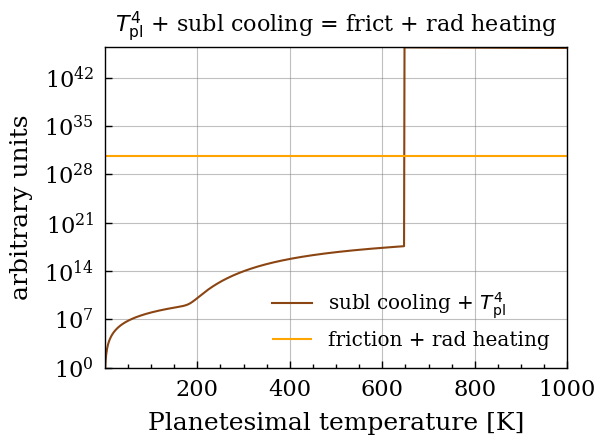

In [76]:
Ts = np.linspace(1, 1000, 1000)

plt.plot(Ts, T_pl_dependent_terms(Ts)[:,None], label=r'subl cooling + $T_\mathrm{pl}^4$', c='saddlebrown')
plt.hlines(T_pl_independent_terms(min_periastron, min_semimajor, r_pls[0]), Ts[0], Ts[-1], label='friction + rad heating', color='orange')
print(T_pl_independent_terms(min_periastron, min_semimajor, r_pls[0]))
#plt.scatter(T_int_min, min_t_ind, color='black', label='T_pl independent terms (min)', zorder=5)
#plt.scatter(T_int_max, max_t_ind, color='black', label='T_pl independent terms (max)', zorder=5)
#plt.fill_between(Ts, min_t_ind, max_t_ind, color='orange', alpha=0.5, label='friction + rad heating')
# plt.vlines(T_int_min[0], ymin=1, ymax=min_t_ind, linestyle='--', colors='grey')
# plt.vlines(T_int_max[0], ymin=1, ymax=max_t_ind, linestyle='--', colors='grey')
#plt.plot(Ts, Ts**4, label=r'$T_\mathrm{pl}^4$', c='steelblue', linestyle='--')
# for i in range(400):
#     plt.plot(Ts, np.full_like(Ts, T_pl_independent_terms(sim)[-i]), c='orange', alpha=0.5)
#     #plt.plot(Ts, np.full_like(Ts, T_pl_independent_terms(sim)[-i]), c='orange')
#     if i == 0:
#         plt.plot(Ts, np.full_like(Ts, T_pl_independent_terms(sim)[i]), label=f'T_pl independent terms', c='orange')
#plt.ylim(1e0, 1e26)
plt.yscale('log')
plt.xlabel('Planetesimal temperature [K]')
plt.ylabel('arbitrary units')
plt.grid()
plt.legend(loc='lower right')
plt.title(r'$T_\mathrm{pl}^4$ + subl cooling = frict + rad heating', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [77]:
def ablation_rate(r_pl, T_pl):
    mass_ablation = -4 * np.pi * (r_pl)**2 * P_sat_vap(T_pl) * np.sqrt(mu_water / (2*np.pi*R_g*T_pl)) *u.M_sun/u.yr
    return mass_ablation

print(ablation_rate(r_pls[2], 400).to('kg/yr'))

-2.0244923987544956e+37 kg / yr


In [79]:
def mass_from_radius(radius):
    return 1000 * u.kg / u.m**3 * (radius*u.AU)**3 * 2/3 * np.pi


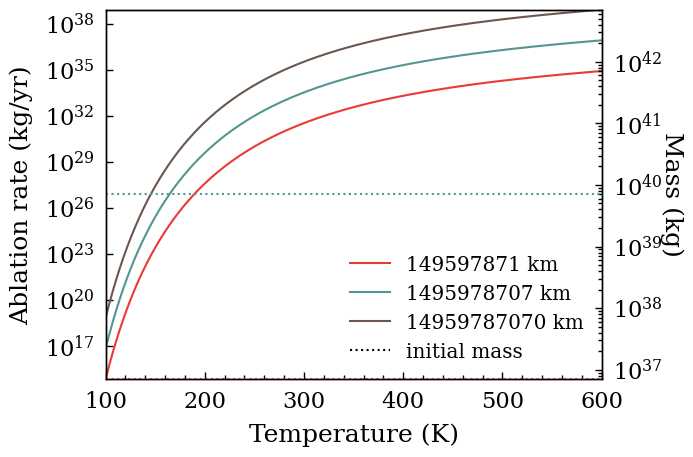

In [ ]:
new_Ts = np.linspace(100, 600, 1000)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

for i in range(3):
    # Plot ablation rate on left axis
    line, = ax1.plot(
        new_Ts,
        -ablation_rate(r_pls[i], new_Ts).to('kg/yr').value,
        label=f'{(r_pls[i]*u.AU).to(u.km):.0f}'
    )

    color = line.get_color()

    # Plot horizontal mass line on right axis
    ax2.hlines(
        mass_from_radius(r_pls[i]).to('kg').value,
        new_Ts[0],
        new_Ts[-1],
        linestyle=':',
        color=color
    )

ax1.set_yscale('log')
ax2.set_yscale('log')
ax2.set_ylim(1, 1e22)
custom_line = Line2D([0], [0], color='black', linestyle=':', label='initial mass')

handles1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(handles=handles1 + [custom_line],
           labels=labels1 + ["initial mass"])

ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("Ablation rate (kg/yr)")
ax2.set_ylabel("Mass (kg)", rotation=270, labelpad=15)
#ax1.grid(alpha=0.5)
plt.show()


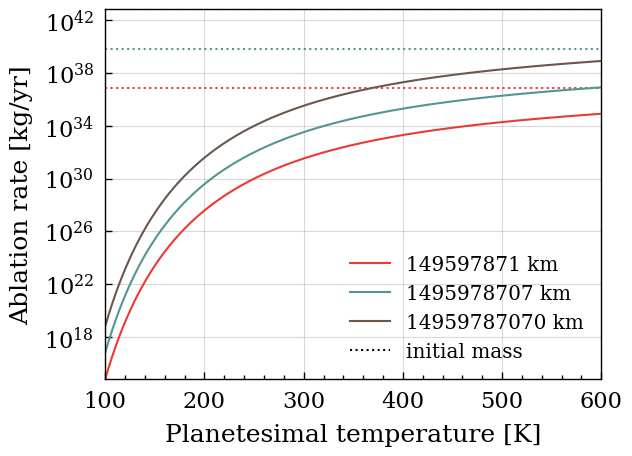

In [86]:
for i in range(3):
    line, = plt.plot(new_Ts, -ablation_rate(r_pls[i], new_Ts).to('kg/yr').value,
        label=f'{(r_pls[i]*u.AU).to(u.km):.0f}'
    )

    color = line.get_color()

    plt.hlines(mass_from_radius(r_pls[i]).to('kg').value, new_Ts[0], new_Ts[-1], linestyle=':',
               color=color)

from matplotlib.lines import Line2D

custom_line = Line2D(
    [0], [0],
    color='black',
    linestyle=':',
    label='initial mass'
)

plt.legend(handles=plt.gca().get_legend_handles_labels()[0] + [custom_line],
           labels=plt.gca().get_legend_handles_labels()[1] + ['initial mass'])

plt.yscale('log')
plt.ylabel('Ablation rate [kg/yr]')
plt.xlabel('Planetesimal temperature [K]')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
m = 1000 * u.kg / u.m**3 * (10 * u.km)**3 * 2/3 * np.pi
print(f'{m.to('kg'):.2e}')

2.09e+18 kg
